In [138]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np

# Read the US-pumpkins.csv file into a DataFrame
pumpkins = pd.read_csv("data/US-pumpkins.csv")

# Filter out any rows that don't use price per bushel
pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel', case=True, regex=True)]
pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
70,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
71,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
72,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
73,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,17.0,17.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
74,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/8/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [139]:
# Count how many cells in each column are empty
pumpkins.isnull().sum()

City Name            0
Type               406
Package              0
Variety              0
Sub Variety        167
Grade              415
Date                 0
Low Price            0
High Price           0
Mostly Low          24
Mostly High         24
Origin               0
Origin District    396
Item Size          114
Color              145
Environment        415
Unit of Sale       404
Quality            415
Condition          415
Appearance         415
Storage            415
Crop               415
Repack               0
Trans Mode         415
Unnamed: 24        415
Unnamed: 25        391
dtype: int64

In [140]:
# Define the columns we want to keep
new_columns = ['Package', 'Month', 'Variety', 'Low Price', 'High Price', 'Date']

# Drop all other columns
pumpkins = pumpkins.drop([c for c in pumpkins.columns if c not in new_columns], axis=1)

In [141]:
# Calculate the average price from the high and low price columns
price = (pumpkins['Low Price'] + pumpkins['High Price']) / 2

# Get the month from the date column
pumpkins['Month'] = pd.to_datetime(pumpkins['Date']).dt.month

# Create a new DataFrame with the month and average price
new_pumpkins = pd.DataFrame({'DayOfYear': day_of_year, 'Month': pumpkins['Month'], 'Package': pumpkins['Package'], 'Low Price': pumpkins['Low Price'], 'High Price': pumpkins['High Price'], 'Price': price})


C:\Users\PC\AppData\Local\Temp\ipykernel_11944\3098198549.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pumpkins['Month'] = pd.to_datetime(pumpkins['Date']).dt.month


In [142]:
# Convert the price of all cells prices by 1 1/9 bushels by dividing by 1 1/9
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'Price'] = price/(1 + 1/9)

# Convert the price of all cells prices by 1/2 bushels by dividing by 1/2
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'Price'] = price/(1/2)

In [143]:
# Print the first 5 rows of the new DataFrame
new_pumpkins.head()

,DayOfYear,Month,Package,Low Price,High Price,Price
70,267,9,1 1/9 bushel cartons,15.0,15.0,13.5
71,267,9,1 1/9 bushel cartons,18.0,18.0,16.2
72,274,10,1 1/9 bushel cartons,18.0,18.0,16.2
73,274,10,1 1/9 bushel cartons,17.0,17.0,15.3
74,281,10,1 1/9 bushel cartons,15.0,15.0,13.5


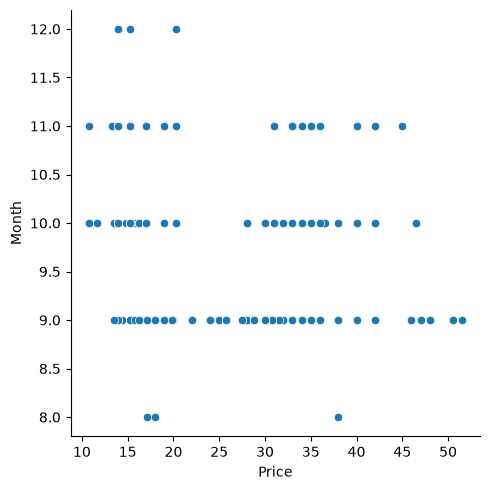

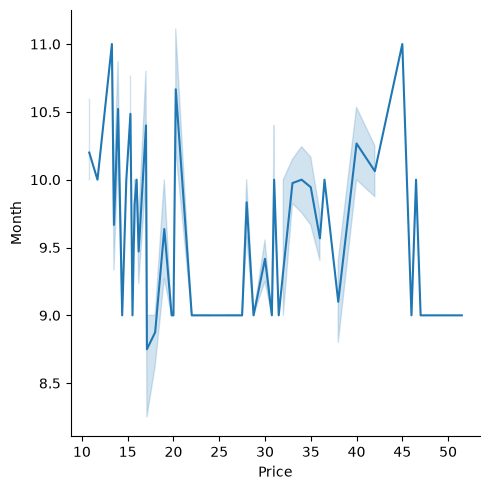

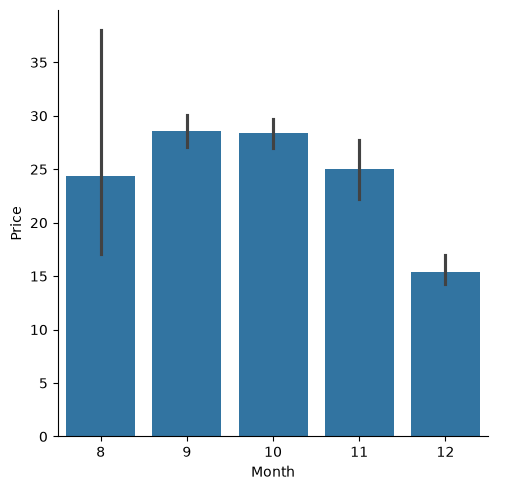

<Axes: >

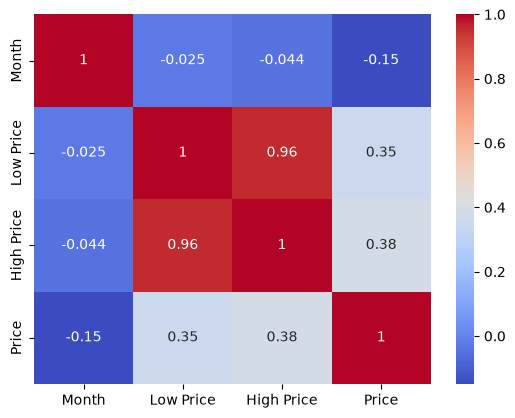

In [144]:
sns.relplot(x="Price", y="Month", data=new_pumpkins)
sns.relplot(x="Price", y="Month", kind="line", data=new_pumpkins)
sns.catplot(x="Month", y="Price", kind="bar", data=new_pumpkins)
plt.show()

#this will make a heat map
correlations = new_pumpkins[['Month', 'Low Price', 'High Price', 'Price']].corr()
sns.heatmap(correlations, annot=True, cmap="coolwarm")

-0.1491291363427862
-0.16690092505934478


C:\Users\PC\AppData\Local\Temp\ipykernel_11944\3794771535.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  day_of_year = pd.to_datetime(pumpkins['Date']).apply(lambda dt: (dt-datetime(dt.year,1,1)).days)


KeyError: 'Variety'

Index(['Month', 'Package', 'Low Price', 'High Price', 'Price'], dtype='str')
